In [1]:
#%ls "../../"
!pip install ../../NEMI

^C


In [4]:
import llc_cutout_dataloader.cutouts_dataset as cutouts_dataset
import cutouts_to_patches.cutouts_to_patches as cutouts_to_patches

In [5]:
import torch
from einops import rearrange
from matplotlib import pyplot as plt

import numpy as np
# from cuml.cluster import HDBSCAN
# from cuml.cluster import DBSCAN
# from cuml.cluster import AgglomerativeClustering
# import cupy as cp
# import cuml.cluster as cuml_cluster
import itertools

from nemi import NEMI, SingleNemi

In [8]:
# from dask.distributed import get_client
#
# # get existing client and shut it down
# client = get_client()
# client.shutdown()
# client.close()

ValueError: No global client found and no address provided

In [9]:
cutouts_dataloader = cutouts_dataset.get_cutout_loader(subset=True, subsample_per_chunk = 64, num_sample_chunks = 1, n_workers=1, batch_size=64)

C:\Users\Jake Tallman\PycharmProjects\DBOF_Representation_Learning\.venv\Lib\site-packages\distributed\node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 59593 instead
  warnings.warn(


<Client: 'tcp://127.0.0.1:59596' processes=1 threads=12, memory=31.10 GiB>
nrp link url : https://jupyterhub-west.nrp-nautilus.io/hub/user-redirect/proxy/59593/status


In [10]:
patch_size = 8
patched_loader = cutouts_to_patches.PatchedDataLoader(cutouts_dataloader, patch_size=patch_size)
print(len(patched_loader))

patches = torch.cat(
    [patches.reshape(patches.shape[0] * patches.shape[1], -1) for patches in patched_loader], dim=0
).numpy()

print(patches.shape)


1
(3904, 512)


C:\Users\Jake Tallman\PycharmProjects\DBOF_Representation_Learning\.venv\Lib\site-packages\torch\utils\data\dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


In [12]:
nemi = NEMI()
single_nemi = SingleNemi()

In [13]:
single_nemi.run(patches)

Fitting the embedding
Predicting the clusters


C:\Users\Jake Tallman\PycharmProjects\DBOF_Representation_Learning\.venv\Lib\site-packages\sklearn\cluster\_agglomerative.py:323: UserWarning: the number of connected components of the connectivity matrix is 21 > 1. Completing it to avoid stopping the tree early.
  connectivity, n_connected_components = _fix_connectivity(


Sorting clusters


In [18]:
single_nemi.embedding.shape
embeded_patches_3d = single_nemi.embedding

In [19]:
def vis_dim_redux(X_d, labels=None, class_subset=None, label_title="class", dims=2):

    labels = labels

    if dims ==2:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111)

        if labels is not None :

            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                c=labels,
                cmap="tab10",
                alpha=0.07,
                s=.1
            )

        else :
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                alpha=0.07,
                s=.1
            )

        ax.set_xlabel("C1")
        ax.set_ylabel("C2")

        legend = ax.legend(*scatter.legend_elements(), title=label_title)
        ax.add_artist(legend)

    if dims == 3:
        fig = plt.figure(figsize=(8,6))
        ax = fig.add_subplot(111, projection='3d')

        if labels is not None :
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                X_d[:,2],
                c=labels,
                s=.1,
                cmap="tab10",
                alpha=0.07
            )

        else :
            scatter = ax.scatter(
                X_d[:,0],
                X_d[:,1],
                X_d[:,2],
                alpha=0.07,
                s=.1
            )


        ax.set_xlabel("C1")
        ax.set_ylabel("C2")
        ax.set_zlabel("C3")

        legend = ax.legend(*scatter.legend_elements(), title=label_title)
        ax.add_artist(legend)

plt.show()


C:\Users\Jake Tallman\PycharmProjects\DBOF_Representation_Learning\.venv\Lib\site-packages\matplotlib\collections.py:1112: UserWarning: Collection without array used. Make sure to specify the values to be colormapped via the `c` argument.
  warnings.warn("Collection without array used. Make sure to "


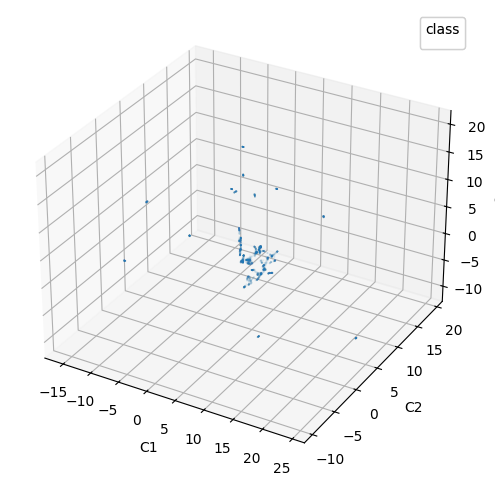

In [20]:
vis_dim_redux(embeded_patches_3d, dims=3)

In [21]:
clusters = single_nemi.clusters
clusters.shape

(3904,)

In [23]:
print(np.unique(clusters).shape)

(30,)


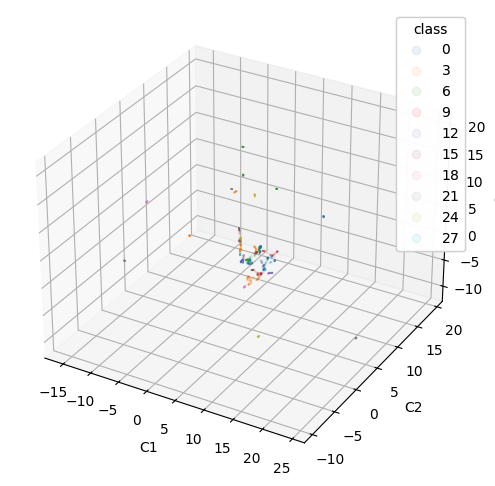

In [22]:
vis_dim_redux(embeded_patches_3d, clusters, dims=3)